In [62]:
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim
import torch
import torch.nn as nn
import matplotlib.patches as patches

from torch.utils.data import Dataset, DataLoader

device = "cuda"
torch.backends.cudnn.benchmark = True

In [63]:
# -----------------------
# 1. Generate diffusion data (Dirichlet BC)
# -----------------------
def diffusion_solver_dirichlet(u0, nu=0.02, dx=1/128, dt=1e-4, n_steps=2000):
    """Explicit finite-difference solver for 1D diffusion (Dirichlet BCs u(0,t)=u(1,t)=0)."""
    u = u0.copy()
    Nx = len(u)
    traj = [u.copy()]
    for _ in range(n_steps):
        un = u.copy()

        # discrete Laplacian on interior points only (no np.roll)
        lap = (un[2:] - 2*un[1:-1] + un[:-2]) / dx**2
        u[1:-1] = un[1:-1] + nu * dt * lap

        # Dirichlet boundaries
        u[0] = 0.0
        u[-1] = 0.0

        traj.append(u.copy())
    return np.stack(traj)  # shape (T, Nx)

def generate_diffusion_data(Nx=128, nu=0.02, dt=1e-4, n_steps=4000):
    dx = 1.0 / (Nx - 1)
    x = np.linspace(0, 1, Nx)

    # initial condition compatible with Dirichlet BC
    u0 = np.sin(2*np.pi * x)   # = 0 at x=0 and x=1

    data = diffusion_solver_dirichlet(u0, nu, dx, dt, n_steps)
    return x, data  # data[t, x]

# -----------------------
# 3. Training setup
# -----------------------
Nx =500
dt0 = 1e-4
nu = 0.02
n_steps = 20000

x, data = generate_diffusion_data(Nx, nu, dt0, n_steps)


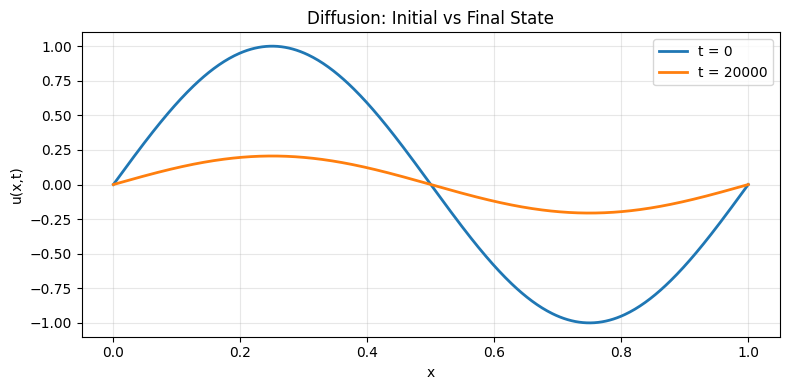

In [64]:
t_plot = n_steps  # or whatever final index you used

plt.figure(figsize=(8,4))
plt.plot(x, data[0], label="t = 0", linewidth=2)
plt.plot(x, data[t_plot], label=f"t = {t_plot}", linewidth=2)
plt.title("Diffusion: Initial vs Final State")
plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [65]:
def sample_one_B(u, R=5, k=5, max_tries=50, u_scale=None, rng=np.random):
    """
    Sample a single Scheme-B training example using an index-space square.

    Square geometry:
        t in [t0-R, t0+R], x in [x0-R, x0+R]

    Returns:
        feats_flat: (k*3,) with [dt_scaled, dx_scaled, u_scaled]
        target: scalar normalized u(t0,x0)
    """
    Nt, Nx = u.shape

    if u_scale is None:
        u_scale = np.max(np.abs(u)) + 1e-8

    for _ in range(max_tries):

        # ---- 1. sample random center ----
        t0 =  rng.randint(0, Nt)
        x0 =  rng.randint(0, Nx)

        # ---- 2. square bounds ----
        t_min = max(0, t0 - R)
        t_max = min(Nt - 1, t0 + R)
        x_min = max(0, x0 - R)
        x_max = min(Nx - 1, x0 + R)

        # ---- 3. collect candidates ----
        cand = []
        for t in range(t_min, t_max + 1):
            for x in range(x_min, x_max + 1):
                if t == t0 and x == x0:
                    continue
                cand.append((t, x))

        if len(cand) < k:
            continue

        # ---- 4. pick k random neighbors ----
        cand = np.array(cand)
        idx = np.random.choice(len(cand), size=k, replace=False)
        neigh = cand[idx]

        # ---- 5. build feature vector ----
        feats = []
        for (tn, xn) in neigh:
            dt_scaled = (t0 - tn)
            dx_scaled = (x0 - xn)
            u_scaled = u[tn, xn] / u_scale
            feats.append([dt_scaled, dx_scaled, u_scaled])

        feats = np.array(feats, dtype=np.float32).reshape(-1)
        target = np.float32(u[t0, x0] / u_scale)
        return feats, target

    raise RuntimeError("Failed to sample B-example; try changing R/k.")


In [66]:
class BDataset(Dataset):
    """
    Scheme-B dataset:
    - u: PDE solution, shape (Nt, Nx)
    - N_samples: number of samples
    """
    def __init__(self, u, N_samples=50000, R=10, k=10, seed=0, pregenerate=False):
        self.u = u
        self.N_samples = N_samples
        self.R = R
        self.k = k
        self.rng = np.random.RandomState(seed)

        # global normalization for u
        self.u_scale = np.max(np.abs(u)) + 1e-8

        self.pregenerate = pregenerate
        if pregenerate:
            print(f"Pre-generating {N_samples} samples...")
            feats = []
            targets = []

            for i in range(N_samples):
                if (i + 1) % 10000 == 0:
                    print(f"  Generated {i+1}/{N_samples}")

                f, t = sample_one_B(
                    self.u,
                    R=self.R,
                    k=self.k,
                    u_scale=self.u_scale,
                    rng=self.rng,
                )
                feats.append(f)
                targets.append(t)

            self.feats_tensor = torch.from_numpy(
                np.asarray(feats, dtype=np.float32)
            )
            self.targets_tensor = torch.from_numpy(
                np.asarray(targets, dtype=np.float32)
            )

            print("Pre-generation complete.")

    def __len__(self):
        return self.N_samples

    def __getitem__(self, idx):
        if self.pregenerate:
            return self.feats_tensor[idx], self.targets_tensor[idx]
        else:
            feats, target = sample_one_B(
                self.u,
                R=self.R,
                k=self.k,
                u_scale=self.u_scale,
                rng=self.rng,
            )
            return (
                torch.from_numpy(feats),
                torch.tensor(target, dtype=torch.float32),
            )


## Linear predictor (professor's formulation)

**Goal:** Minimize  
$$\min_\Theta \ \|U_{\mathrm{act}} - \sum_{i,j,k} U_{\mathrm{NN}}(i)\, \Delta t^j\, \Delta x^k\, \Theta_{ijk} \|^2 + \lambda \|\Theta\|^2$$

**Steps:**
1. **Predefine a library of variables**  
   Fix exponent ranges, e.g. \(j,k \in \{-2,-1,0,1,2\}\).  
   Each basis term is \(\phi_{jk} = \sum_n U_{\mathrm{NN}}(n)\, \Delta t_n^j\, \Delta x_n^k\) over the \(k\) neighbors.

2. **Build design matrix X and targets y**  
   For each sample (center point + neighbors), one row of X = the 25 library features; y = \(U_{\mathrm{act}}\) at the center.

3. **Optimization (ridge regression)**  
   Solve \(\Theta = (X^\top X + \lambda I)^{-1} X^\top y\). No neural network needed for this linear predictor.

4. **Connection to finite-difference stencil**  
   The 1D diffusion Laplacian uses the stencil **1, -2, 1** (second derivative).  
   With the library, the learned \(\Theta\) for spatial terms (e.g. \(k=-1,0,1\)) can recover stencil-like coefficients, so the model implicitly learns a finite-difference–type structure.

In [67]:
# -----------------------
# Linear predictor: predefined library + ridge optimization
# -----------------------
# Library exponents j, k in {-2,-1,0,1,2} → 25 basis functions
J_LIST = list(range(-2, 3))
K_LIST = list(range(-2, 3))
dx_phys = 1.0 / (Nx - 1)
dt_phys = dt0
n_basis = len(J_LIST) * len(K_LIST)  # 25

def build_library_row(u, t0, x0, neigh, J_LIST, K_LIST, dt_phys, dx_phys):
    """One row of X: for each (j,k), feature = Σ_n U_NN(n) * Δt_n^j * Δx_n^k."""
    row = []
    for j in J_LIST:
        for k in K_LIST:
            val = 0.0
            for (tn, xn) in neigh:
                dt_n = dt_phys * (t0 - tn)
                dx_n = dx_phys * (x0 - xn)
                u_nn = u[tn, xn]
                # avoid 0^negative; use small epsilon for stability
                dt_j = (dt_n ** j) if (j >= 0 or abs(dt_n) > 1e-12) else 0.0
                dx_k = (dx_n ** k) if (k >= 0 or abs(dx_n) > 1e-12) else 0.0
                val += u_nn * dt_j * dx_k
            row.append(val)
    return np.array(row, dtype=np.float64)

def build_X_y_library(u, n_samples, R, k, dt_phys, dx_phys, J_LIST, K_LIST, seed=0):
    """Sample (t0,x0) and k neighbors like BDataset; build X (library features) and y = U_act."""
    rng = np.random.RandomState(seed)
    Nt, Nx = u.shape
    X = np.zeros((n_samples, n_basis))
    y = np.zeros(n_samples)
    for i in range(n_samples):
        for _ in range(100):
            t0 = rng.randint(0, Nt)
            x0 = rng.randint(0, Nx)
            t_min = max(0, t0 - R)
            t_max = min(Nt - 1, t0 + R)
            x_min = max(0, x0 - R)
            x_max = min(Nx - 1, x0 + R)
            cand = [(t, x) for t in range(t_min, t_max + 1) for x in range(x_min, x_max + 1)
                    if not (t == t0 and x == x0)]
            if len(cand) < k:
                continue
            cand = np.array(cand)
            idx = rng.choice(len(cand), size=k, replace=False)
            neigh = [tuple(cand[i]) for i in idx]
            X[i] = build_library_row(u, t0, x0, neigh, J_LIST, K_LIST, dt_phys, dx_phys)
            y[i] = u[t0, x0]
            break
    return X, y

# Build training data for linear predictor
n_samples_lib = 20000
X_lib, y_lib = build_X_y_library(data, n_samples_lib, R=10, k=10, dt_phys=dt_phys, dx_phys=dx_phys,
                                  J_LIST=J_LIST, K_LIST=K_LIST)
print("Library: j in", J_LIST, ", k in", K_LIST, "→", n_basis, "basis functions")
print("X_lib shape:", X_lib.shape, ", y_lib shape:", y_lib.shape)

Library: j in [-2, -1, 0, 1, 2] , k in [-2, -1, 0, 1, 2] → 25 basis functions
X_lib shape: (20000, 25) , y_lib shape: (20000,)


In [68]:
# Ridge regression: min_Θ ||y - X@Θ||^2 + λ||Θ||^2  →  Θ = (X'X + λI)^{-1} X'y
lam = 1e-6  # regularization
XtX = X_lib.T @ X_lib + lam * np.eye(n_basis)
Xty = X_lib.T @ y_lib
Theta_ridge = np.linalg.solve(XtX, Xty)

# Training MSE (linear predictor)
y_pred_lib = X_lib @ Theta_ridge
mse_lib = np.mean((y_lib - y_pred_lib) ** 2)
print(f"Linear predictor (ridge) train MSE = {mse_lib:.6e}")

# Reshape Θ for interpretation: (len(J_LIST), len(K_LIST)) for (j,k) → stencil-like view
Theta_grid = Theta_ridge.reshape(len(J_LIST), len(K_LIST))
print("Learned Θ (rows=j, cols=k); spatial slice j=0, k=-1,0,1 ≈ stencil weights:")
print("  k=-1,0,1:", Theta_grid[J_LIST.index(0), :])  # j=0 row: time-constant, spatial terms

Linear predictor (ridge) train MSE = 1.022155e-04
Learned Θ (rows=j, cols=k); spatial slice j=0, k=-1,0,1 ≈ stencil weights:
  k=-1,0,1: [ 3.24536269e-10  5.55061290e-07  1.00483664e-01 -1.21110450e-02
 -1.60593582e+00]


In [69]:
# Helper: single-point prediction and eval for the new linear (library+ridge) model
def predict_linear_library(u, t0, x0, neigh, Theta_ridge, J_LIST, K_LIST, dt_phys, dx_phys):
    """Predict u(t0,x0) using library features and Theta_ridge."""
    row = build_library_row(u, t0, x0, neigh, J_LIST, K_LIST, dt_phys, dx_phys)
    return float(np.dot(row, Theta_ridge))

def eval_linear_library(u, Theta_ridge, N_test, R, k, J_LIST, K_LIST, dt_phys, dx_phys, seed=456):
    """Test MSE for the new linear (library+ridge) model."""
    X_test, y_test = build_X_y_library(u, N_test, R, k, dt_phys, dx_phys, J_LIST, K_LIST, seed=seed)
    y_pred = X_test @ Theta_ridge
    return float(np.mean((y_test - y_pred) ** 2))

def build_X_y_feats_for_cumulative(u, n_samples, R, k, dt_phys, dx_phys, J_LIST, K_LIST, u_scale, seed=0):
    """Build X_lib, y_raw, and feats_mlp for the same n_samples (for cumulative error: same points for linear library and MLP)."""
    n_basis = len(J_LIST) * len(K_LIST)
    rng = np.random.RandomState(seed)
    Nt, Nx = u.shape
    X_lib = np.zeros((n_samples, n_basis))
    y_raw = np.zeros(n_samples)
    feats_mlp = np.zeros((n_samples, k * 3), dtype=np.float32)
    for i in range(n_samples):
        for _ in range(100):
            t0 = rng.randint(0, Nt)
            x0 = rng.randint(0, Nx)
            t_min = max(0, t0 - R)
            t_max = min(Nt - 1, t0 + R)
            x_min = max(0, x0 - R)
            x_max = min(Nx - 1, x0 + R)
            cand = [(t, x) for t in range(t_min, t_max + 1) for x in range(x_min, x_max + 1)
                    if not (t == t0 and x == x0)]
            if len(cand) < k:
                continue
            cand = np.array(cand)
            idx = rng.choice(len(cand), size=k, replace=False)
            neigh = [tuple(cand[j]) for j in idx]
            X_lib[i] = build_library_row(u, t0, x0, neigh, J_LIST, K_LIST, dt_phys, dx_phys)
            y_raw[i] = u[t0, x0]
            f = []
            for (tn, xn) in neigh:
                f.extend([t0 - tn, x0 - xn, u[tn, xn] / u_scale])
            feats_mlp[i] = np.array(f, dtype=np.float32)
            break
    return X_lib, y_raw, feats_mlp

In [70]:
class LinearIntegrator(nn.Module):
    def __init__(self, k=5):
        super().__init__()
        self.lin = nn.Linear(k * 3, 1)

    def forward(self, x):
        return self.lin(x).squeeze(-1)


In [71]:
class MLPIntegrator(nn.Module):
    def __init__(self, k=5, hidden=128, num_layers=3):
        super().__init__()
        in_dim = k * 3
        layers = [nn.Linear(in_dim, hidden), nn.ReLU()]

        for _ in range(num_layers - 2):
            layers += [nn.Linear(hidden, hidden), nn.ReLU()]

        layers.append(nn.Linear(hidden, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


In [72]:
def train_integrator_B(
    model,
    u,
    epochs=50,
    batch_size=2048,
    k=5,
    R=5,
    N_samples=100000,
    lr=1e-3,
    pregenerate=True,
):
    """
    Minimal training loop for Scheme-B integrators.

    Args:
        model: torch.nn.Module (linear or MLP)
        u: numpy array (Nt, Nx)
    Returns:
        model: trained model
        train_losses: list of epoch-wise MSE
    """
    device = "cuda"
    model = model.to(device)

    dataset = BDataset(
        u,
        N_samples=N_samples,
        R=R,
        k=k,
        pregenerate=pregenerate,
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=True,
    )

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    train_losses = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for feats, target in loader:
            feats = feats.to(device)
            target = target.to(device)

            opt.zero_grad()
            pred = model(feats)
            loss = loss_fn(pred, target)
            loss.backward()
            opt.step()

            total_loss += loss.item() * feats.size(0)

        avg_loss = total_loss / len(dataset)
        train_losses.append(avg_loss)

        print(f"[Epoch {epoch+1}/{epochs}] train MSE = {avg_loss:.6e}")

    return model, train_losses


In [73]:
def eval_integrator_B(model, u, R, k, N_test=10000, batch_size=4096,):
    device = "cuda"
    model.eval()
    test_ds = BDataset( u, N_samples=N_test,R=R,k=k, seed=123,pregenerate=True,    )
    loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0,pin_memory=True,)
    loss_fn = nn.MSELoss()
    total_loss = 0.0
    with torch.no_grad():
        for feats, target in loader:
            feats = feats.to(device)
            target = target.to(device)
            pred = model(feats)
            loss = loss_fn(pred, target)
            total_loss += loss.item() * feats.size(0)
    avg_loss = total_loss / N_test
    print(f"[Eval] MSE = {avg_loss:.6e}")
    return avg_loss

In [74]:
def visualize_B_compare_models(u, model_mlp, R=5, k=5, Theta_ridge=None, J_LIST=None, K_LIST=None, dt_phys=None, dx_phys=None):
    """Compare new linear (library+ridge) vs MLP. Pass Theta_ridge and library params for the linear model."""
    device = "cuda"
    model_mlp.eval()

    Nt, Nx = u.shape

    # ---- choose one random center ----
    t0 = np.random.randint(0, Nt)
    x0 = np.random.randint(0, Nx)

    # ---- square neighborhood ----
    t_min = max(0, t0 - R)
    t_max = min(Nt - 1, t0 + R)
    x_min = max(0, x0 - R)
    x_max = min(Nx - 1, x0 + R)

    cand = [(t, x) for t in range(t_min, t_max + 1)
                    for x in range(x_min, x_max + 1)
                    if not (t == t0 and x == x0)]
    cand = np.array(cand)

    idx = np.random.choice(len(cand), size=k, replace=False)
    neigh = cand[idx]
    neigh_tuples = [tuple(cand[i]) for i in idx]

    # ---- linear (library+ridge): pred from library features ----
    if Theta_ridge is not None and J_LIST is not None and K_LIST is not None and dt_phys is not None and dx_phys is not None:
        pred_lin = predict_linear_library(u, t0, x0, neigh_tuples, Theta_ridge, J_LIST, K_LIST, dt_phys, dx_phys)
    else:
        pred_lin = np.nan

    # ---- MLP: 15-dim feats ----
    u_scale = np.max(np.abs(u)) + 1e-8
    feats = []
    for (tn, xn) in neigh:
        feats.append([t0 - tn, x0 - xn, u[tn, xn] / u_scale])
    feats = np.array(feats, dtype=np.float32).reshape(1, -1)
    feats_torch = torch.from_numpy(feats).to(device)

    with torch.no_grad():
        pred_mlp = model_mlp(feats_torch).item() * u_scale

    true = u[t0, x0]

    # ---- plotting ----
    fig, axes = plt.subplots(
        1, 2,
        figsize=(9, 4),
        sharey=True,
        gridspec_kw={"wspace": 0.08},  # panels closer
    )

    for ax, title, pred in zip(
        axes,
        ["Linear (library+ridge)", "MLP"],
        [pred_lin, pred_mlp],
    ):
        # square
        rect = plt.Rectangle(
            (x_min, t_min),
            x_max - x_min,
            t_max - t_min,
            fill=False,
            edgecolor="blue",
            linewidth=1.8,
        )
        ax.add_patch(rect)

        # neighbors
        ax.scatter(neigh[:, 1], neigh[:, 0], s=110, label="neighbors")
        for (tn, xn) in neigh:
            ax.plot([x0, xn], [t0, tn], alpha=0.6)

        # target
        ax.scatter([x0], [t0], c="red", s=180, label="target", zorder=5)

        rel_err = (true - pred) / (true + 1e-12) * 100 if not np.isnan(pred) else float('nan')
        ax.set_title(
            f"{title}\n"
            f"pred = {pred:.5f}, rel err = {rel_err:.2f}%",
            fontsize=10,
        )

        ax.set_xlim(x_min - 2, x_max + 2)
        ax.set_ylim(t_max + 2, t_min - 2)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel("x")
    for ax in axes:
        ax.invert_yaxis()
    axes[0].set_ylabel("t (time index, upward)")

    # ---- shared legend ----
    handles, labels = axes[0].get_legend_handles_labels()
     

    # ---- shared true value ----
    fig.suptitle(
        f"True value at target: u(t₀, x₀) = {true:.5f}",
        y=1.05,
        fontsize=11,
    )
    # Flip y-axis to have increasing upward
    
    plt.tight_layout()
    plt.show()


In [75]:
def save_integrator_model(model, model_type, path, config):
    """
    Save a trained integrator model.

    Args:
        model: trained torch.nn.Module
        model_type: str ("linear" or "mlp")
        config: dict with required hyperparameters
    """
    torch.save(
        {
            "model_type": model_type,
            "model_state_dict": model.state_dict(),
            "config": config,
        },
        path,
    )


In [76]:
def load_integrator_model(path):
    """
    Load a saved integrator model.
    """
    device = "cuda"
    checkpoint = torch.load(path, map_location=device)

    model_type = checkpoint["model_type"]
    config = checkpoint["config"]

    if model_type == "linear":
        model = LinearIntegrator(k=config["k"])
    elif model_type == "mlp":
        model = MLPIntegrator(
            k=config["k"],
            hidden=config["hidden"],
            num_layers=config["num_layers"],
        )
    else:
        raise ValueError(f"Unknown model type: {model_type}")

    model.load_state_dict(checkpoint["model_state_dict"])
    model = model.to(device)
    model.eval()

    return model, config


In [77]:
# =========================
# Experiments
# =========================
 
R = 10
k = 10
epochs = 150
batch_size = 2048
N_samples = 100000
lr = 1e-3

In [78]:
# Linear model = library+ridge (Theta_ridge from cells above); no training.
# MLP is trained in the next cell.


In [79]:
model_mlp =  MLPIntegrator(k=k, hidden=128, num_layers=3)
model_mlp, loss_mlp = train_integrator_B(
    model_mlp,
    data,
    epochs=epochs,
    batch_size=batch_size,
    k=k,
    R=R,
    N_samples=N_samples,
    lr=lr,
)


Pre-generating 100000 samples...
  Generated 10000/100000
  Generated 20000/100000
  Generated 30000/100000
  Generated 40000/100000
  Generated 50000/100000
  Generated 60000/100000
  Generated 70000/100000
  Generated 80000/100000
  Generated 90000/100000
  Generated 100000/100000
Pre-generation complete.
[Epoch 1/150] train MSE = 9.687719e-02
[Epoch 2/150] train MSE = 1.246646e-02
[Epoch 3/150] train MSE = 6.979745e-03
[Epoch 4/150] train MSE = 5.031305e-03
[Epoch 5/150] train MSE = 3.875093e-03
[Epoch 6/150] train MSE = 3.090992e-03
[Epoch 7/150] train MSE = 2.531582e-03
[Epoch 8/150] train MSE = 2.106665e-03
[Epoch 9/150] train MSE = 1.737400e-03
[Epoch 10/150] train MSE = 1.478893e-03
[Epoch 11/150] train MSE = 1.232703e-03
[Epoch 12/150] train MSE = 1.051964e-03
[Epoch 13/150] train MSE = 8.747562e-04
[Epoch 14/150] train MSE = 7.383796e-04
[Epoch 15/150] train MSE = 6.341937e-04
[Epoch 16/150] train MSE = 5.589345e-04
[Epoch 17/150] train MSE = 4.692293e-04
[Epoch 18/150] train

In [80]:
# New linear (library+ridge)
test_loss_linear_lib = eval_linear_library(data, Theta_ridge, N_test=20_000, R=R, k=k,
    J_LIST=J_LIST, K_LIST=K_LIST, dt_phys=dt_phys, dx_phys=dx_phys)
print(f"[Eval] Linear (library+ridge) MSE = {test_loss_linear_lib:.6e}")

# MLP
test_loss_mlp = eval_integrator_B(model_mlp, data, R=R, k=k, N_test=20_000)

print(f"Linear (library+ridge) test MSE: {test_loss_linear_lib:.6e}")
print(f"MLP test MSE:                    {test_loss_mlp:.6e}")


[Eval] Linear (library+ridge) MSE = 1.023631e-04
Pre-generating 20000 samples...
  Generated 10000/20000
  Generated 20000/20000
Pre-generation complete.
[Eval] MSE = 1.600327e-04
Linear (library+ridge) test MSE: 1.023631e-04
MLP test MSE:                    1.600327e-04


In [81]:
# ===== Save models =====

# Linear (library+ridge): save Theta_ridge and config to .npz
np.savez(
    "linear_library_ridge_Square.npz",
    Theta_ridge=Theta_ridge,
    J_LIST=np.array(J_LIST),
    K_LIST=np.array(K_LIST),
    dt_phys=dt_phys,
    dx_phys=dx_phys,
    R=R,
    k=k,
)

# MLP: save to .pth
torch.save(
    {
        "model_type": "mlp",
        "state_dict": model_mlp.state_dict(),
        "config": {
            "k": k,
            "R": R,
            "hidden": 128,
            "num_layers": 3,
            "u_scale": np.max(np.abs(data)) + 1e-8,
        },
    },
    "small_mlp_integrator_Square.pth",
)

print("Models saved: linear_library_ridge_Square.npz, small_mlp_integrator_Square.pth")


Models saved: linear_library_ridge_Square.npz, small_mlp_integrator_Square.pth


In [82]:
# ===== Load models =====

# Load MLP
ckpt = torch.load("small_mlp_integrator_Square.pth", map_location="cuda", weights_only=False)
if ckpt["model_type"] == "mlp":
    model_mlp = MLPIntegrator(
        k=ckpt["config"]["k"],
        hidden=ckpt["config"]["hidden"],
        num_layers=ckpt["config"]["num_layers"],
    )
else:
    raise ValueError("Expected mlp checkpoint")
model_mlp.load_state_dict(ckpt["state_dict"])
model_mlp = model_mlp.to("cuda")
model_mlp.eval()
print(f"Loaded MLP with config: {ckpt['config']}")

# Load linear (library+ridge) from .npz
lin_ckpt = np.load("linear_library_ridge_Square.npz", allow_pickle=True)
Theta_ridge = lin_ckpt["Theta_ridge"]
J_LIST = list(lin_ckpt["J_LIST"])
K_LIST = list(lin_ckpt["K_LIST"])
dt_phys = float(lin_ckpt["dt_phys"])
dx_phys = float(lin_ckpt["dx_phys"])
print("Loaded linear (library+ridge): Theta_ridge, J_LIST, K_LIST, dt_phys, dx_phys")


Loaded MLP with config: {'k': 10, 'R': 10, 'hidden': 128, 'num_layers': 3, 'u_scale': np.float64(0.9999950554033061)}
Loaded linear (library+ridge): Theta_ridge, J_LIST, K_LIST, dt_phys, dx_phys


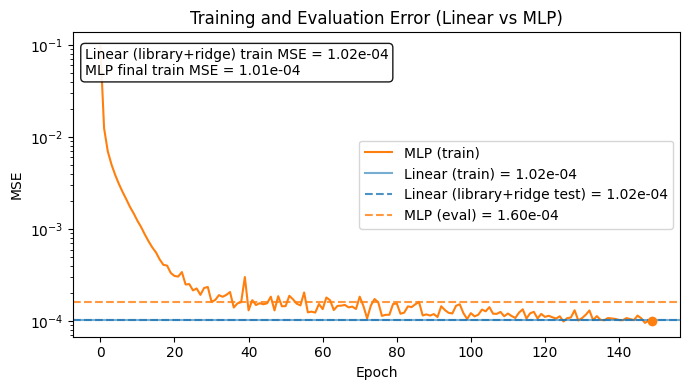

In [83]:
plt.figure(figsize=(7, 4))

# MLP training curve (linear = library+ridge has no iterative training)
plt.semilogy(loss_mlp, label="MLP (train)", color="C1")

# Mark final MLP point
final_mlp = loss_mlp[-1]
epoch_last = len(loss_mlp) - 1
plt.scatter(epoch_last, final_mlp, color="C1", zorder=5)

# Linear (library+ridge): single train MSE and test horizontal line
plt.axhline(mse_lib, color="C0", linestyle="-", alpha=0.6, label=f"Linear (train) = {mse_lib:.2e}")
plt.axhline(
    test_loss_linear_lib,
    color="C0",
    linestyle="--",
    alpha=0.8,
    label=f"Linear (library+ridge test) = {test_loss_linear_lib:.2e}"
)
plt.axhline(
    test_loss_mlp,
    color="C1",
    linestyle="--",
    alpha=0.8,
    label=f"MLP (eval) = {test_loss_mlp:.2e}"
)

# ---- Text box: Linear = library+ridge (no train curve), MLP = final train ----
textstr = (
    f"Linear (library+ridge) train MSE = {mse_lib:.2e}\n"
    f"MLP final train MSE = {final_mlp:.2e}"
)

plt.text(
    0.02, 0.95, textstr,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
)

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training and Evaluation Error (Linear vs MLP)")
plt.legend()
plt.grid(False)   # <-- remove grey grid lines
plt.tight_layout()
plt.show()


C:\Users\amt35\AppData\Local\Temp\ipykernel_17272\3860242465.py:105: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


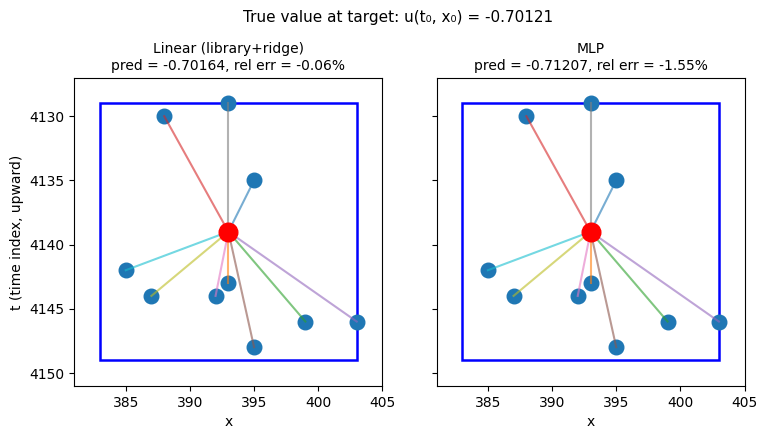

In [104]:
visualize_B_compare_models(data, model_mlp, R=R, k=k,
    Theta_ridge=Theta_ridge, J_LIST=J_LIST, K_LIST=K_LIST, dt_phys=dt_phys, dx_phys=dx_phys)



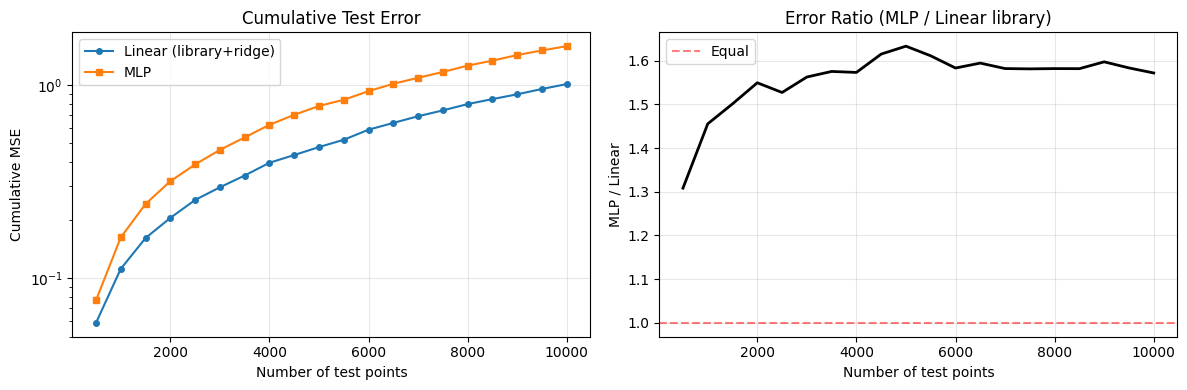

In [85]:
# Cumulative test error comparison (new linear library+ridge vs MLP, same test points)
n_points = 10000
step = 500
u_scale = np.max(np.abs(data)) + 1e-8

X_lib, y_raw, feats_mlp = build_X_y_feats_for_cumulative(
    data, n_points, R, k, dt_phys, dx_phys, J_LIST, K_LIST, u_scale, seed=456
)

cum_err_lin, cum_err_mlp = [], []
total_lin, total_mlp = 0.0, 0.0

model_mlp.eval()
with torch.no_grad():
    for i in range(0, n_points, step):
        end = min(i + step, n_points)
        sz = end - i
        # Linear (library+ridge): raw predictions
        pred_lin = X_lib[i:end] @ Theta_ridge
        # MLP: scaled output -> raw
        feats_batch = torch.from_numpy(feats_mlp[i:end]).to(device)
        pred_mlp_raw = model_mlp(feats_batch).cpu().numpy() * u_scale
        y_batch = y_raw[i:end]
        total_lin += np.sum((y_batch - pred_lin) ** 2)
        total_mlp += np.sum((y_batch - pred_mlp_raw) ** 2)
        cum_err_lin.append(total_lin)
        cum_err_mlp.append(total_mlp)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Cumulative error
x = np.arange(step, n_points + 1, step)
ax1.semilogy(x, cum_err_lin, 'o-', label='Linear (library+ridge)', color='C0', markersize=4)
ax1.semilogy(x, cum_err_mlp, 's-', label='MLP', color='C1', markersize=4)
ax1.set_xlabel('Number of test points')
ax1.set_ylabel('Cumulative MSE')
ax1.set_title('Cumulative Test Error')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Error ratio
ratio = np.array(cum_err_mlp) / np.array(cum_err_lin)
ax2.plot(x, ratio, 'k-', linewidth=2)
ax2.axhline(1, color='r', linestyle='--', alpha=0.5, label='Equal')
ax2.set_xlabel('Number of test points')
ax2.set_ylabel('MLP / Linear')
ax2.set_title('Error Ratio (MLP / Linear library)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()